In [2]:
# Step 1: check actual filenames to confirm pattern
import os
DATA_PATH = "/kaggle/input/datasets/rahnumatasnim1604103/bangladeshi-banknote-dataset/dataset"
files = os.listdir(DATA_PATH)
print("Total files:", len(files))
print(files[:10])

Total files: 70542
['100 (850).png', '100 (2571).png', '100 (1650).png', '10 (1522).png', '10 (4061).png', '20 (12018).png', '500 (977).png', '20 (1544).png', '2 (1596).png', '10 (3127).png']


In [3]:
import re, shutil, random
from pathlib import Path
from collections import defaultdict

RAW_DIR = Path("/kaggle/input/datasets/rahnumatasnim1604103/bangladeshi-banknote-dataset/dataset")
OUT_DIR = Path("/kaggle/working/data/yolo")
SPLIT_RATIO = 0.85
MAX_PER_CLASS = 2500   # speed er jonno limit, chaile barao/komao

all_files = list(RAW_DIR.glob("*.png")) + list(RAW_DIR.glob("*.jpg"))
print("Total images found:", len(all_files))

def get_class(fname):
    match = re.match(r"^(\S+)\s*\(", fname)
    return match.group(1) if match else None

classes_found = sorted(set(get_class(f.name) for f in all_files if get_class(f.name)))
print("Classes found:", classes_found)

class_files = defaultdict(list)
for f in all_files:
    cls = get_class(f.name)
    if cls:
        class_files[cls].append(f)

for split in ["train", "val"]:
    (OUT_DIR / "images" / split).mkdir(parents=True, exist_ok=True)
    (OUT_DIR / "labels" / split).mkdir(parents=True, exist_ok=True)

class_id_map = {cls: i for i, cls in enumerate(classes_found)}

for cls, files in class_files.items():
    random.shuffle(files)
    files = files[:MAX_PER_CLASS]
    split_idx = int(len(files) * SPLIT_RATIO)
    train_files, val_files = files[:split_idx], files[split_idx:]
    class_id = class_id_map[cls]

    for split, split_files in [("train", train_files), ("val", val_files)]:
        for f in split_files:
            new_name = f"{cls}_{f.name}".replace(" ", "_")
            shutil.copy(f, OUT_DIR / "images" / split / new_name)
            label_path = OUT_DIR / "labels" / split / (Path(new_name).stem + ".txt")
            with open(label_path, "w") as lf:
                lf.write(f"{class_id} 0.5 0.5 1.0 1.0\n")

print("Done. Class ID map:", class_id_map)

Total images found: 70542
Classes found: ['10', '100', '1000', '2', '20', '5', '50', '500']
Done. Class ID map: {'10': 0, '100': 1, '1000': 2, '2': 3, '20': 4, '5': 5, '50': 6, '500': 7}


In [4]:
yaml_content = """path: /kaggle/working/data/yolo
train: images/train
val: images/val

names:
  0: 10
  1: 100
  2: 1000
  3: 2
  4: 20
  5: 5
  6: 50
  7: 500
"""

with open("/kaggle/working/data.yaml", "w") as f:
    f.write(yaml_content)

print("data.yaml created")

data.yaml created


In [5]:
!pip install ultralytics -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 36.0 MB/s eta 0:00:0000:01


In [6]:
import torch
print("GPU available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")

GPU available: True
GPU name: Tesla T4


In [7]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")   # auto-downloads nano pretrained weights

results = model.train(
    data="/kaggle/working/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    project="/kaggle/working/runs",
    name="taka_detector"
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.104 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fracti

In [8]:
import os
weights_path = "/kaggle/working/runs/taka_detector/weights/best.pt"
print("Exists:", os.path.exists(weights_path))
print("Size:", os.path.getsize(weights_path) / (1024*1024), "MB")

Exists: True
Size: 5.195703506469727 MB


In [9]:
from IPython.display import FileLink
FileLink(weights_path)

/kaggle/working/runs/taka_detector/weights/best.pt

Testing on: /kaggle/working/data/yolo/images/val/20_20_(472).png

Detections:
{'class': '20', 'confidence': 0.9949, 'bbox': {'x1': 0.03, 'y1': 0.07, 'x2': 255.94, 'y2': 116.83}}


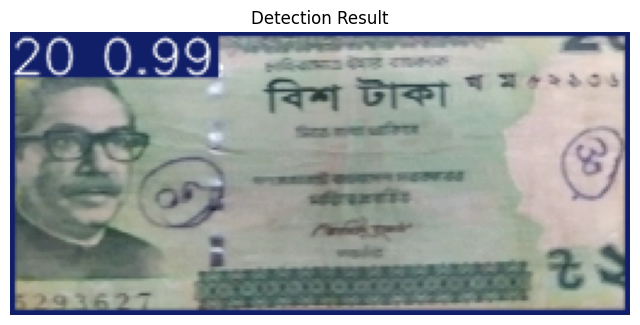

In [10]:
from ultralytics import YOLO
import cv2
from PIL import Image
import matplotlib.pyplot as plt

model = YOLO("/kaggle/working/runs/taka_detector/weights/best.pt")

def run_inference(image_path, conf_threshold=0.5):
    results = model.predict(source=image_path, conf=conf_threshold, verbose=False)
    result = results[0]

    detections = []
    for box in result.boxes:
        class_id = int(box.cls[0])
        class_name = model.names[class_id]
        confidence = float(box.conf[0])
        x1, y1, x2, y2 = box.xyxy[0].tolist()

        detections.append({
            "class": class_name,
            "confidence": round(confidence, 4),
            "bbox": {"x1": round(x1,2), "y1": round(y1,2), "x2": round(x2,2), "y2": round(y2,2)}
        })

    return detections, result

test_image = "/kaggle/working/data/yolo/images/val/" + os.listdir("/kaggle/working/data/yolo/images/val")[0]
print("Testing on:", test_image)

detections, result = run_inference(test_image)
print("\nDetections:")
for d in detections:
    print(d)

result_img = result.plot()
plt.figure(figsize=(8,8))
plt.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title("Detection Result")
plt.show()